# IFC → Mesh Demo
2 Wände + 1 Stütze + Deckenplatte 4×4×0.2 m  
**Ziel:** IFC aufbauen, vernetzen, 3D-Plot zeigen — kein Solver.

In [1]:
import numpy as onp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import ifcopenshell
import ifcopenshell.api
import ifcopenshell.geom
from jax_fem.generate_mesh import box_mesh, Mesh
import pathlib

DATA_DIR = pathlib.Path('../data')
DATA_DIR.mkdir(exist_ok=True)

print('ifcopenshell:', ifcopenshell.__version__)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              

ifcopenshell: 0.8.5


## 1 — IFC-Modell erzeugen

```
   y
   ▲
4m │  ████████████  Wand_B (y=3.8..4.0)
   │  █          █
   │  █    ■     █  Stütze_M (x=1.9, y=1.9)
   │  █          █
0  │  ████████████  Wand_A (y=0..0.2)
   └──────────────► x
      0          4m

Deckenplatte: z=2.8..3.0 m, 4×4 m
```

In [2]:
def _box_vf(x0, y0, z0, dx, dy, dz):
    v = [(x0,y0,z0),(x0+dx,y0,z0),(x0+dx,y0+dy,z0),(x0,y0+dy,z0),
         (x0,y0,z0+dz),(x0+dx,y0,z0+dz),(x0+dx,y0+dy,z0+dz),(x0,y0+dy,z0+dz)]
    f = [(0,1,2),(0,2,3),(4,6,5),(4,7,6),(0,1,5),(0,5,4),
         (2,3,7),(2,7,6),(0,3,7),(0,7,4),(1,2,6),(1,6,5)]
    return v, f

model   = ifcopenshell.api.run('project.create_file', version='IFC4')
project = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcProject', name='Demo')
ifcopenshell.api.run('unit.assign_unit', model, length={'is_metric': True, 'raw': 'METRES'})
ctx  = ifcopenshell.api.run('context.add_context', model, context_type='Model')
body = ifcopenshell.api.run('context.add_context', model, context_type='Model',
                             context_identifier='Body', target_view='MODEL_VIEW', parent=ctx)
site     = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcSite',     name='Site')
building = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcBuilding', name='Gebäude')
storey   = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcBuildingStorey', name='EG')
ifcopenshell.api.run('aggregate.assign_object', model, products=[site],     relating_object=project)
ifcopenshell.api.run('aggregate.assign_object', model, products=[building], relating_object=site)
ifcopenshell.api.run('aggregate.assign_object', model, products=[storey],   relating_object=building)

BAUTEILE = [
    # (ifc_class, name,       x0,   y0,   z0,  dx,   dy,   dz)
    ('IfcWall',   'Wand_A',   0.0,  0.0,  0.0, 4.0,  0.2,  2.8),
    ('IfcWall',   'Wand_B',   0.0,  3.8,  0.0, 4.0,  0.2,  2.8),
    ('IfcColumn', 'Stütze_M', 1.9,  1.9,  0.0, 0.2,  0.2,  2.8),
    ('IfcSlab',   'Decke_D1', 0.0,  0.0,  2.8, 4.0,  4.0,  0.2),
]

elements_info = []
for ifc_class, name, x0, y0, z0, dx, dy, dz in BAUTEILE:
    elem = ifcopenshell.api.run('root.create_entity', model, ifc_class=ifc_class, name=name)
    v, f = _box_vf(x0, y0, z0, dx, dy, dz)
    rep  = ifcopenshell.api.run('geometry.add_mesh_representation', model,
                                 context=body, vertices=[v], faces=[f])
    ifcopenshell.api.run('geometry.assign_representation', model, product=elem, representation=rep)
    ifcopenshell.api.run('spatial.assign_container', model, relating_structure=storey, products=[elem])
    bmin = onp.array([x0, y0, z0])
    bmax = onp.array([x0+dx, y0+dy, z0+dz])
    dims = bmax - bmin
    elements_info.append({'name': name, 'type': ifc_class, 'bbox': (bmin, bmax),
                           'color': {'IfcWall':'#a0c4ff','IfcColumn':'#ff6b6b','IfcSlab':'#b9fbc0'}[ifc_class]})
    print(f'  {ifc_class:12s} {name:12s}:  {dims[0]:.1f}×{dims[1]:.2f}×{dims[2]:.1f} m')

ifc_path = str(DATA_DIR / 'demo_statik.ifc')
model.write(ifc_path)
print(f'\nIFC gespeichert: {ifc_path}')

  IfcWall      Wand_A      :  4.0×0.20×2.8 m
  IfcWall      Wand_B      :  4.0×0.20×2.8 m
  IfcColumn    Stütze_M    :  0.2×0.20×2.8 m
  IfcSlab      Decke_D1    :  4.0×4.00×0.2 m

IFC gespeichert: ../data/demo_statik.ifc


## 2 — Vernetzung (HEX8, box_mesh pro Bauteil)

Jedes Bauteil erhält ein eigenes strukturiertes Hex8-Netz.  
Netzgröße: `MESH_SIZE` in Metern.

In [3]:
MESH_SIZE = 0.2   # m — Elementgröße

mesh_parts = []   # pro Bauteil: {name, type, color, points, cells_global}
all_pts    = []
all_cells  = []
offset     = 0

for info, (ifc_class, name, x0, y0, z0, dx, dy, dz) in zip(elements_info, BAUTEILE):
    nx = max(1, int(round(dx / MESH_SIZE)))
    ny = max(1, int(round(dy / MESH_SIZE)))
    nz = max(1, int(round(dz / MESH_SIZE)))

    m   = box_mesh(Nx=nx, Ny=ny, Nz=nz, domain_x=dx, domain_y=dy, domain_z=dz)
    pts = m.points + onp.array([x0, y0, z0])
    cells_loc = m.cells_dict['hexahedron']
    cells_glob = cells_loc + offset

    mesh_parts.append({
        'name'  : name,
        'type'  : ifc_class,
        'color' : info['color'],
        'pts'   : pts,
        'cells' : cells_glob,
        'n_pts' : len(pts),
        'n_el'  : len(cells_loc),
    })
    all_pts.append(pts)
    all_cells.append(cells_glob)
    offset += len(pts)
    print(f'  {name:12s}  nx={nx} ny={ny} nz={nz}  →  {len(pts):5d} Knoten  {len(cells_loc):5d} Elemente')

points_all = onp.vstack(all_pts)
cells_all  = onp.vstack(all_cells)

print(f'\nGesamt:  {len(points_all):6d} Knoten  {len(cells_all):6d} HEX8-Elemente')
print(f'x: [{points_all[:,0].min():.2f}, {points_all[:,0].max():.2f}] m')
print(f'y: [{points_all[:,1].min():.2f}, {points_all[:,1].max():.2f}] m')
print(f'z: [{points_all[:,2].min():.2f}, {points_all[:,2].max():.2f}] m')

  Wand_A        nx=20 ny=1 nz=14  →    630 Knoten    280 Elemente
  Wand_B        nx=20 ny=1 nz=14  →    630 Knoten    280 Elemente
  Stütze_M      nx=1 ny=1 nz=14  →     60 Knoten     14 Elemente
  Decke_D1      nx=20 ny=20 nz=1  →    882 Knoten    400 Elemente

Gesamt:    2202 Knoten     974 HEX8-Elemente
x: [0.00, 4.00] m
y: [0.00, 4.00] m
z: [0.00, 3.00] m


## 3 — 3D-Visualisierung

Jedes Bauteil wird in seiner eigenen Farbe dargestellt.  
Sichtbare Außenflächen jedes HEX8-Elements als transparente Patches.

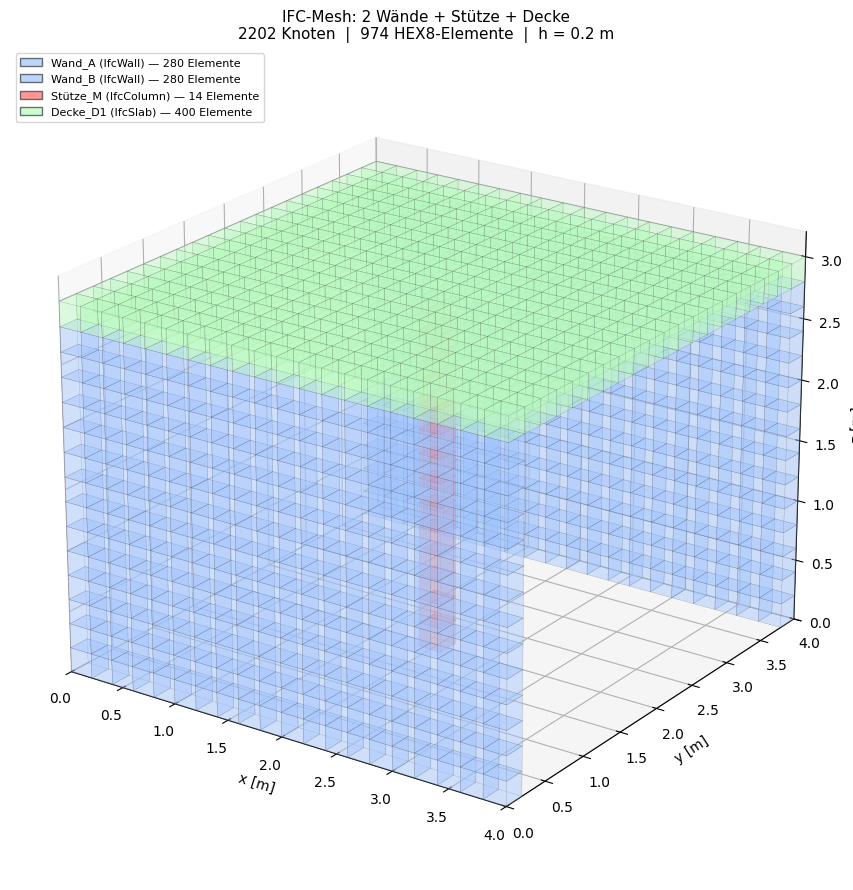

Plot gespeichert: ../data/vtk/demo_mesh_3d.png


In [4]:
# HEX8-Flächen-Index: 6 Seiten, je 4 Knoten (VTK-Reihenfolge)
HEX_FACES = [
    [0, 1, 2, 3],  # Boden
    [4, 5, 6, 7],  # Deckel
    [0, 1, 5, 4],  # Vorne
    [3, 2, 6, 7],  # Hinten
    [0, 3, 7, 4],  # Links
    [1, 2, 6, 5],  # Rechts
]

fig = plt.figure(figsize=(14, 9))
ax  = fig.add_subplot(111, projection='3d')

legend_handles = []

for part in mesh_parts:
    pts   = part['pts']
    cells = part['cells']          # globale Indizes
    color = part['color']

    quads = []
    # Nur jedes n-te Element zeichnen, sonst zu viele Patches
    step = max(1, len(cells) // 300)
    for cell in cells[::step]:
        # Lokale Knoten aus globalen Indizes
        local_pts = pts[cell - (part['cells'][0].min())]  # Offset zurückrechnen
        # Einfacher: direkt global
        gpts = points_all[cell]
        for face in HEX_FACES:
            quads.append(gpts[face])

    poly = Poly3DCollection(quads, alpha=0.25, linewidth=0.2)
    poly.set_facecolor(color)
    poly.set_edgecolor('#333333')
    ax.add_collection3d(poly)

    # Legende-Proxy
    from matplotlib.patches import Patch
    legend_handles.append(Patch(facecolor=color, edgecolor='#333', alpha=0.7,
                                 label=f"{part['name']} ({part['type']}) — {part['n_el']} Elemente"))

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_title(f'IFC-Mesh: 2 Wände + Stütze + Decke\n'
              f'{len(points_all)} Knoten  |  {len(cells_all)} HEX8-Elemente  |  h = {MESH_SIZE} m', fontsize=11)

ax.set_xlim(0, 4); ax.set_ylim(0, 4); ax.set_zlim(0, 3.2)
ax.set_box_aspect([4, 4, 3.2])
ax.view_init(elev=22, azim=-55)

ax.legend(handles=legend_handles, loc='upper left', fontsize=8)
plt.tight_layout()

out_png = str(DATA_DIR / 'vtk' / 'demo_mesh_3d.png')
import os; os.makedirs(str(DATA_DIR / 'vtk'), exist_ok=True)
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print('Plot gespeichert:', out_png)

## 4 — Interaktiver 3D-Plot mit PyVista

PyVista rendert das Netz interaktiv (drehen, zoomen).  
Jedes Bauteil hat seine eigene Farbe.

In [5]:
import pyvista as pv

pv.set_jupyter_backend('trame')    # interaktives 3D-Widget im Notebook

COLOR_MAP = {
    'IfcWall'  : '#a0c4ff',
    'IfcColumn': '#ff6b6b',
    'IfcSlab'  : '#b9fbc0',
}

plotter = pv.Plotter(window_size=(900, 600))
plotter.set_background('white')

for part in mesh_parts:
    pts   = part['pts']
    cells = part['cells']

    # PyVista UnstructuredGrid aus HEX8-Zellen aufbauen
    # Zell-Array: [8, n0, n1, ..., n7] für jede Zelle
    # Knoten sind bauteil-lokal → lokale Indizes berechnen
    local_offset = int(cells.min())
    local_cells  = cells - local_offset

    cell_array = onp.hstack([
        onp.full((len(local_cells), 1), 8, dtype=onp.int64),
        local_cells.astype(onp.int64)
    ]).flatten()
    cell_types = onp.full(len(local_cells), pv.CellType.HEXAHEDRON)

    grid = pv.UnstructuredGrid(cell_array, cell_types, pts)
    plotter.add_mesh(grid,
                     color=COLOR_MAP[part['type']],
                     show_edges=True,
                     edge_color='gray',
                     opacity=0.9,
                     label=part['name'])

plotter.add_legend(size=(0.25, 0.15), loc='upper right')
plotter.add_axes()
plotter.camera_position = [(10, -8, 8), (2, 2, 1.5), (0, 0, 1)]
plotter.show(title='IFC-Mesh — 2 Wände + Stütze + Decke')

Widget(value='<iframe src="http://localhost:55846/index.html?ui=P_0x1164d7e20_0&reconnect=auto" class="pyvista…

## 5 — Netzstatistik

In [6]:
print('=' * 50)
print(f'  Elementgröße h = {MESH_SIZE} m')
print('=' * 50)
for part in mesh_parts:
    print(f"  {part['type']:12s}  {part['name']:12s}: "
          f"{part['n_pts']:5d} Knoten  {part['n_el']:5d} HEX8")
print('-' * 50)
print(f'  GESAMT              : {len(points_all):5d} Knoten  {len(cells_all):5d} HEX8')
print(f'  DOF (3 × Knoten)    : {len(points_all)*3:6d}')
print()
print('Nächste Schritte:')
print('  → GMSH für echtes Tet4-Volumennetz (schließt Bauteil-Kontakte)')
print('  → JaxFEM-Solver (GESAMTSTATIK.ipynb)')
print('  → IFC-Property-Mapping: Material → E-Modul')

  Elementgröße h = 0.2 m
  IfcWall       Wand_A      :   630 Knoten    280 HEX8
  IfcWall       Wand_B      :   630 Knoten    280 HEX8
  IfcColumn     Stütze_M    :    60 Knoten     14 HEX8
  IfcSlab       Decke_D1    :   882 Knoten    400 HEX8
--------------------------------------------------
  GESAMT              :  2202 Knoten    974 HEX8
  DOF (3 × Knoten)    :   6606

Nächste Schritte:
  → GMSH für echtes Tet4-Volumennetz (schließt Bauteil-Kontakte)
  → JaxFEM-Solver (GESAMTSTATIK.ipynb)
  → IFC-Property-Mapping: Material → E-Modul
